In [10]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\smartphone_usage_feature_engineered.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (7500, 21)


In [11]:
X = df.drop(columns=[
    "addicted_label",
    "transaction_id",
    "user_id",
    "addiction_level"
])

y = df["addicted_label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7500, 17)
Target shape: (7500,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6000, 17)
X_test shape: (1500, 17)
y_train shape: (6000,)
y_test shape: (1500,)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessing setup completed!")
print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Preprocessing setup completed!
Categorical features: ['gender', 'stress_level', 'academic_work_impact']
Number of numerical features: 14


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [15]:
logistic_model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [16]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1500


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

Model Evaluation Results
------------------------
Accuracy: 0.8987
Precision: 0.9136
Recall: 0.9463
F1-Score: 0.9297


In [18]:
from sklearn.metrics import classification_report

print("Classification Report")
print("---------------------")
print(classification_report(y_test, y_pred))

Classification Report
---------------------
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       438
           1       0.91      0.95      0.93      1062

    accuracy                           0.90      1500
   macro avg       0.89      0.86      0.87      1500
weighted avg       0.90      0.90      0.90      1500



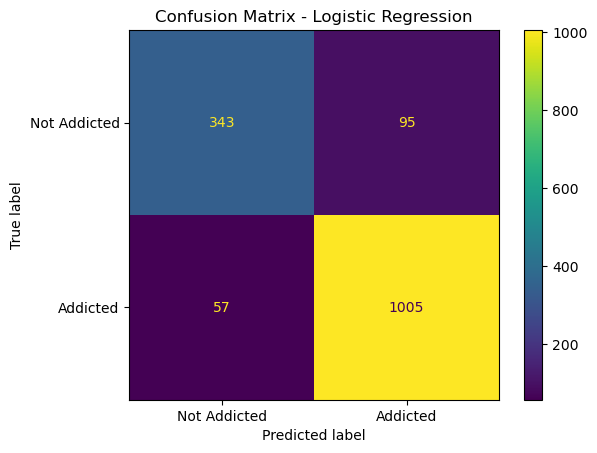

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Addicted", "Addicted"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9575


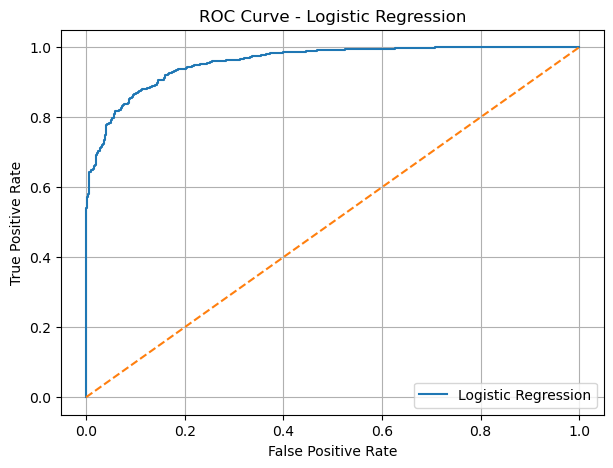

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

In [22]:
import joblib

model_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\logistic_regression_model.pkl"

joblib.dump(logistic_model, model_path)

print("Model saved successfully!")
print("Saved location:", model_path)

Model saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\logistic_regression_model.pkl


In [23]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [24]:
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [25]:
rf_pred = random_forest_model.predict(X_test)

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(rf_pred))

Random Forest predictions generated successfully!
Number of predictions: 1500


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Evaluation Results")
print("--------------------------------")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-Score:", round(rf_f1, 4))

Random Forest Evaluation Results
--------------------------------
Accuracy: 0.9347
Precision: 0.9564
Recall: 0.951
F1-Score: 0.9537


In [27]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("-----------------------------------")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       438
           1       0.96      0.95      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



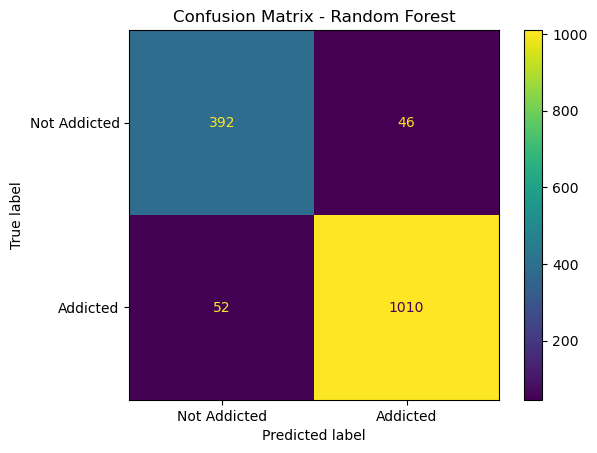

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, rf_pred)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Addicted", "Addicted"]
)

rf_disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [29]:
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC Score:", round(rf_roc_auc, 4))

Random Forest ROC-AUC Score: 0.9895


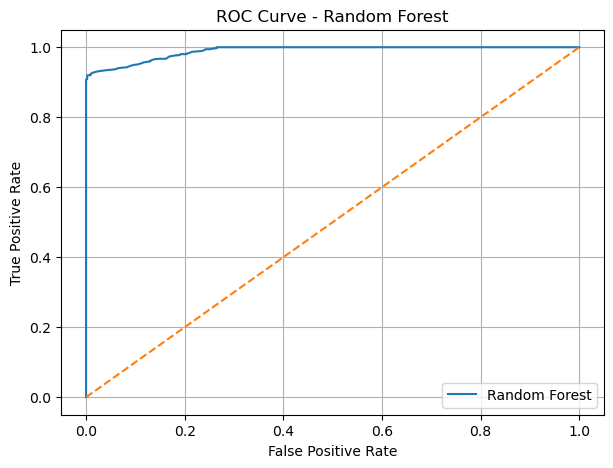

In [30]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

In [31]:
rf_model_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_model.pkl"

joblib.dump(random_forest_model, rf_model_path)

print("Random Forest model saved successfully!")
print("Saved location:", rf_model_path)

Random Forest model saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_model.pkl


In [32]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1-Score": [f1, rf_f1],
    "ROC-AUC": [roc_auc, rf_roc_auc]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8987,0.9136,0.9463,0.9297,0.9575
1,Random Forest,0.9347,0.9564,0.9510,0.9537,0.9895


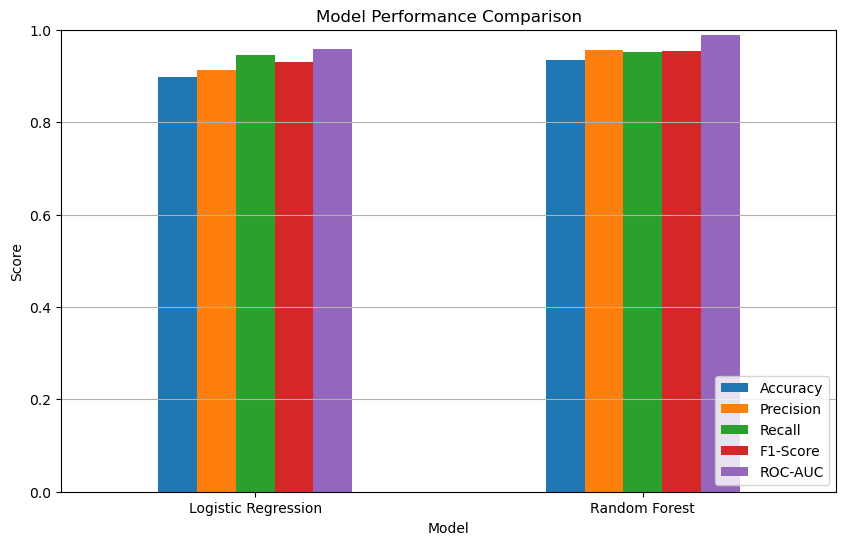

In [33]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [34]:
comparison_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\model_comparison.csv"

comparison.to_csv(comparison_path, index=False)

print("Model comparison saved successfully!")
print("Saved location:", comparison_path)

Model comparison saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\model_comparison.csv


In [35]:
best_model_name = comparison.loc[
    comparison["F1-Score"].idxmax(), "Model"
]

print("Model with the higher F1-score:", best_model_name)

Model with the higher F1-score: Random Forest


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

rf_classifier = random_forest_model.named_steps["classifier"]

feature_importances = rf_classifier.feature_importances_

encoded_features = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
10,numerical__social_media_hours,0.267214
9,numerical__daily_screen_time_hours,0.209726
16,numerical__weekend_screen_time,0.138982
18,numerical__screen_to_sleep_ratio,0.104233
17,numerical__total_leisure_hours,0.089179
21,numerical__productive_time_ratio,0.042884
11,numerical__gaming_hours,0.022870
13,numerical__sleep_hours,0.020022
19,numerical__weekend_screen_time_increase,0.019164
12,numerical__work_study_hours,0.016484


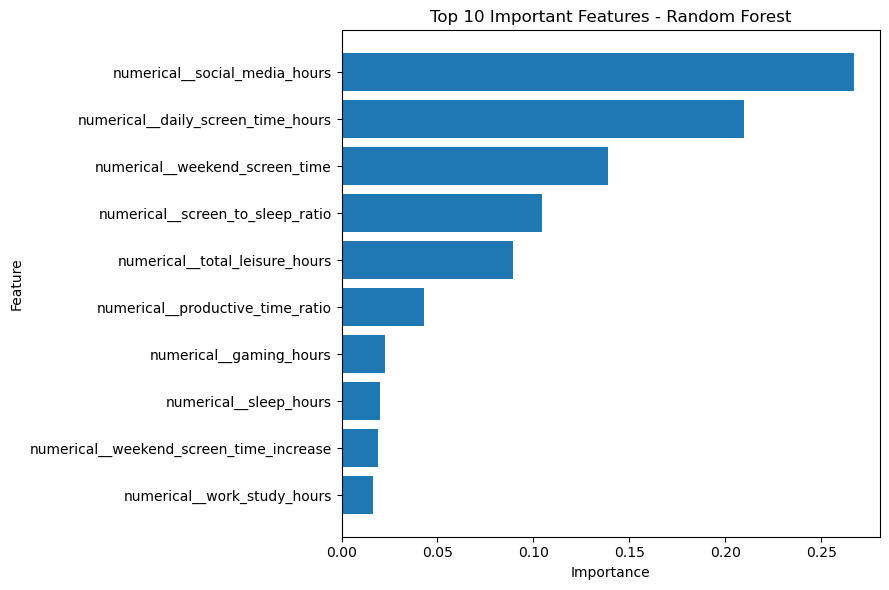

In [37]:
top_features = importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")

plt.tight_layout()
plt.show()

In [38]:
importance_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\feature_importance.csv"

importance_df.to_csv(importance_path, index=False)

print("Feature importance saved successfully!")
print("Saved location:", importance_path)

Feature importance saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\feature_importance.csv


In [39]:
print("FINAL MODEL SUMMARY")
print("-------------------")
print("Logistic Regression F1-Score:", round(f1, 4))
print("Random Forest F1-Score:", round(rf_f1, 4))
print("Logistic Regression ROC-AUC:", round(roc_auc, 4))
print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))
print("Model with higher F1-score:", best_model_name)

FINAL MODEL SUMMARY
-------------------
Logistic Regression F1-Score: 0.9297
Random Forest F1-Score: 0.9537
Logistic Regression ROC-AUC: 0.9575
Random Forest ROC-AUC: 0.9895
Model with higher F1-score: Random Forest


In [40]:
final_model_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_final_model.pkl"

joblib.dump(random_forest_model, final_model_path)

print("Final model saved successfully!")
print("Saved location:", final_model_path)

Final model saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_final_model.pkl


In [41]:
importance_df.head(10)

,Feature,Importance
10,numerical__social_media_hours,0.267214
9,numerical__daily_screen_time_hours,0.209726
16,numerical__weekend_screen_time,0.138982
18,numerical__screen_to_sleep_ratio,0.104233
17,numerical__total_leisure_hours,0.089179
21,numerical__productive_time_ratio,0.042884
11,numerical__gaming_hours,0.022870
13,numerical__sleep_hours,0.020022
19,numerical__weekend_screen_time_increase,0.019164
12,numerical__work_study_hours,0.016484


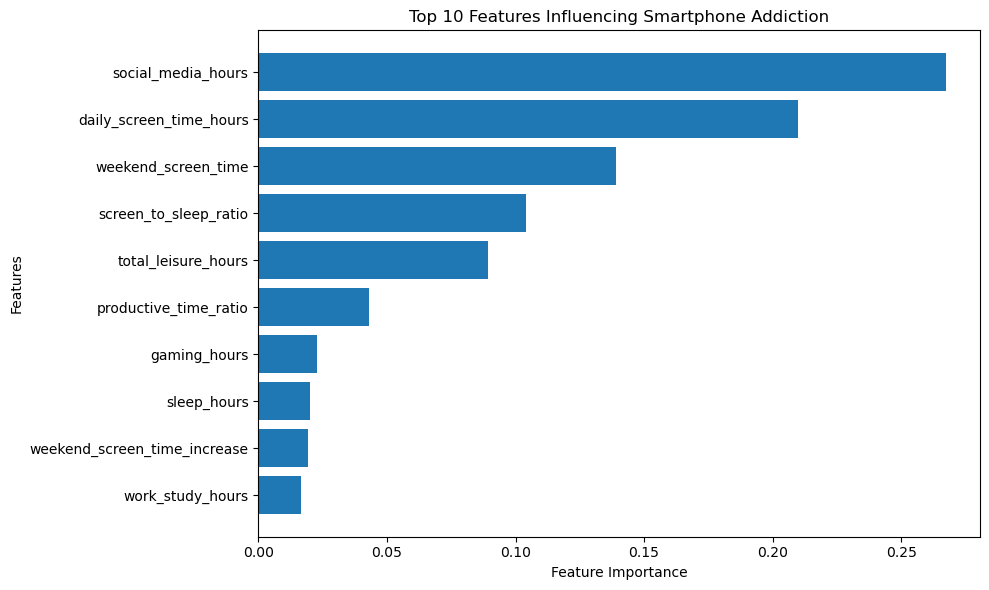

In [42]:
top_features = importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"].str.replace(
        "numerical__", "", regex=False
    ),
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing Smartphone Addiction")

plt.tight_layout()
plt.show()

In [4]:
import joblib

rf_model_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\random_forest_final_model.pkl"

random_forest_model = joblib.load(rf_model_path)

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [5]:
import pandas as pd

rf_classifier = random_forest_model.named_steps["classifier"]

feature_importances = rf_classifier.feature_importances_

encoded_features = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature importance recreated successfully!")

importance_df.head(10)

Feature importance recreated successfully!


,Feature,Importance
0,numerical__social_media_hours,0.267214
1,numerical__daily_screen_time_hours,0.209726
2,numerical__weekend_screen_time,0.138982
3,numerical__screen_to_sleep_ratio,0.104233
4,numerical__total_leisure_hours,0.089179
5,numerical__productive_time_ratio,0.042884
6,numerical__gaming_hours,0.022870
7,numerical__sleep_hours,0.020022
8,numerical__weekend_screen_time_increase,0.019164
9,numerical__work_study_hours,0.016484


In [6]:
importance_report = importance_df.head(10).copy()

importance_report["Importance_Percentage"] = (
    importance_report["Importance"] * 100
).round(2)

importance_report["Feature"] = (
    importance_report["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

importance_report[
    ["Feature", "Importance_Percentage"]
]

,Feature,Importance_Percentage
0,social_media_hours,26.72
1,daily_screen_time_hours,20.97
2,weekend_screen_time,13.90
3,screen_to_sleep_ratio,10.42
4,total_leisure_hours,8.92
5,productive_time_ratio,4.29
6,gaming_hours,2.29
7,sleep_hours,2.00
8,weekend_screen_time_increase,1.92
9,work_study_hours,1.65


In [7]:
importance_report_path = r"C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\top_feature_importance_report.csv"

importance_report.to_csv(
    importance_report_path,
    index=False
)

print("Feature importance report saved successfully!")
print("Saved location:", importance_report_path)

Feature importance report saved successfully!
Saved location: C:\Users\sushm\OneDrive\Desktop\Digital-Wellbeing-Analytics\data\processed\top_feature_importance_report.csv


In [8]:
print("KEY PROJECT INSIGHTS")
print("--------------------")
print("1. Social media usage was the most influential feature.")
print("2. Daily and weekend screen time were also important.")
print("3. Screen-time-related features contributed strongly to predictions.")
print("4. Feature importance shows model influence, not direct causation.")

KEY PROJECT INSIGHTS
--------------------
1. Social media usage was the most influential feature.
2. Daily and weekend screen time were also important.
3. Screen-time-related features contributed strongly to predictions.
4. Feature importance shows model influence, not direct causation.
